In [2]:
import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt

In [ ]:


pattern_size = (10, 7)     
square_size = 25.0          
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 200, 1e-6)
images = sorted(glob.glob("frames_for_cali/*.jpg"))

objp = np.zeros((1, pattern_size[0]*pattern_size[1], 3), np.float64)
objp[0, :, :2] = np.mgrid[0:pattern_size[0], 0:pattern_size[1]].T.reshape(-1, 2)
objp *= square_size

objpoints, imgpoints = [], []

for f in images:
    img = cv2.imread(f)
    if img is None:
        continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ret, corners = cv2.findChessboardCorners(gray, pattern_size,
                    cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE)
    if ret:
        cv2.cornerSubPix(gray, corners, (5,5), (-1,-1), criteria)
        objpoints.append(objp.copy())
        imgpoints.append(corners.astype(np.float64))

if len(objpoints) < 5:
    raise RuntimeError("Not enough valid detections (need ≥6).")

h, w = gray.shape[:2]
K = np.zeros((3,3))
D = np.zeros((4,1))
rms, K, D, rvecs, tvecs = cv2.fisheye.calibrate(
    objpoints, imgpoints, (w, h),
    K, D, None, None,
    flags=0, criteria=criteria
)

print(f"RMS error: {rms:.3f}\nK:\n{K}\nD:\n{D.ravel()}")


RMS error: 872.354
K:
[[ 1.32862141e+03 -1.69189654e+01  1.30096561e+03]
 [ 0.00000000e+00  1.32523445e+03  9.72465607e+02]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
D:
[  -4.66019644   67.66997848   28.36689544 -925.33680956]


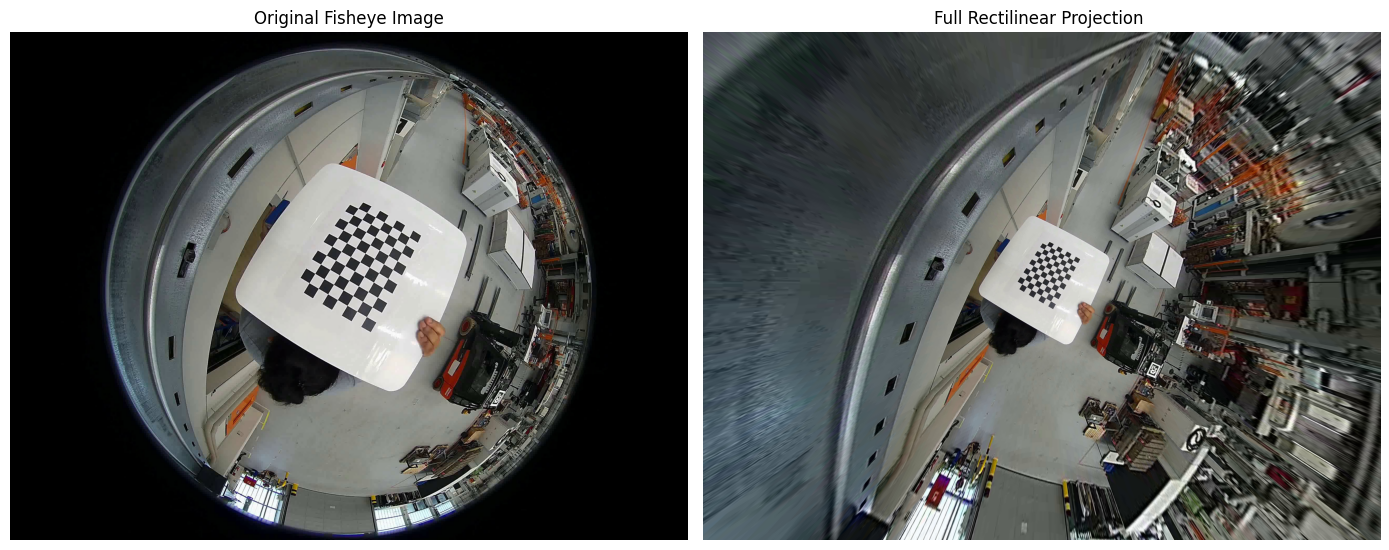

In [4]:
import cv2
import numpy as np

def undistort_fisheye(image, fisheye_params, fov_deg=150, out_size=(1280, 720)):

    cx, cy = fisheye_params["cx"], fisheye_params["cy"]
    radius = fisheye_params["radius"]
    theta_max = fisheye_params["theta_max_rad"]

    W, H = out_size
    fx = fy = (W/2) / np.tan(np.deg2rad(fov_deg/2))
    i, j = np.meshgrid(np.arange(W), np.arange(H))
    x = (i - W/2) / fx
    y = (j - H/2) / fy
    z = np.ones_like(x)

    norm = np.sqrt(x**2 + y**2 + z**2)
    x, y, z = x/norm, y/norm, z/norm

    theta = np.arccos(z)  
    r = radius * np.sin(theta) / np.sin(theta_max)
    phi = np.arctan2(y, x)

    map_x = cx + r * np.cos(phi)
    map_y = cy + r * np.sin(phi)

    map_x = map_x.astype(np.float32)
    map_y = map_y.astype(np.float32)

    undistorted = cv2.remap(image, map_x, map_y, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)
    return undistorted



fisheye_params = {
    "width": 2592,
    "height": 1944,
    "cx": 1296.0,
    "cy": 972.0,
    "radius": 952.56,
    "theta_max_rad": 1.5708  
}

img = cv2.imread("frames_for_cali/frame_00000.jpg")
rectified = undistort_fisheye(img, fisheye_params, fov_deg=140, out_size=(2592,1944))
orig_rgb = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
rectified = cv2.cvtColor(rectified, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.title("Original Fisheye Image")
plt.imshow(orig_rgb)
plt.axis("off")

plt.subplot(1,2,2)
plt.title(f"Full Rectilinear Projection ")
plt.imshow(rectified)
plt.axis("off")
plt.tight_layout()
plt.show()


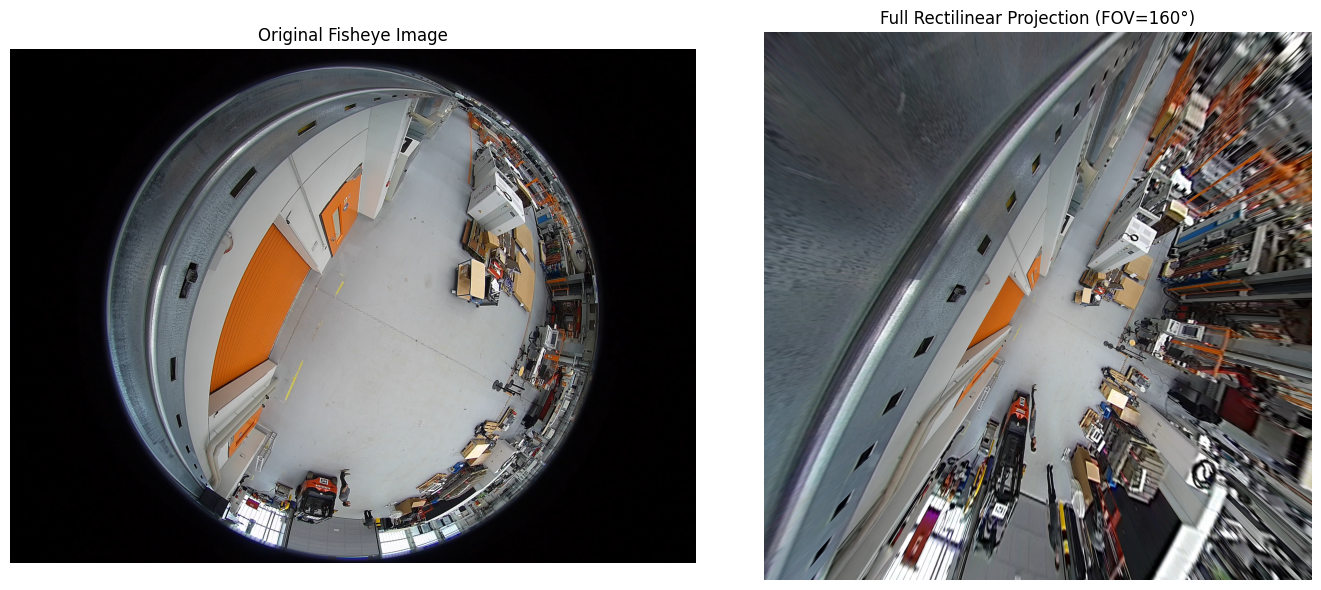

In [10]:

fisheye_params = {
    "width": 2592,
    "height": 1944,
    "cx": 1296.0,
    "cy": 972.0,
    "radius": 952.56,
    "theta_max_rad": 1.5708  
}


fisheye_img = cv2.imread("20251104_115055.png")
Hf, Wf = fisheye_params["height"], fisheye_params["width"]
cx_f, cy_f = fisheye_params["cx"], fisheye_params["cy"]
radius, theta_max = fisheye_params["radius"], fisheye_params["theta_max_rad"]


RECT_W, RECT_H = 2560,2560
VIEW_FOV = 160.0                    
VIEW_FOV_RAD = np.deg2rad(VIEW_FOV)
focal = (RECT_W / 2) / np.tan(VIEW_FOV_RAD / 2)

x_rect, y_rect = np.meshgrid(np.arange(RECT_W), np.arange(RECT_H))
x_norm = (x_rect - RECT_W / 2) / focal
y_norm = (y_rect - RECT_H / 2) / focal
z = np.ones_like(x_norm)

dirs = np.stack([x_norm, y_norm, z], axis=-1)
r = np.linalg.norm(dirs, axis=-1)
dirs /= np.maximum(r, 1e-8)[..., None]


theta = np.arccos(dirs[..., 2])            
phi = np.arctan2(dirs[..., 1], dirs[..., 0]) 
theta = np.minimum(theta, theta_max)

r_fish = radius * (theta / theta_max)
u_fish = cx_f + r_fish * np.cos(phi)
v_fish = cy_f + r_fish * np.sin(phi)


map_x = u_fish.astype(np.float32)
map_y = v_fish.astype(np.float32)
rectilinear = cv2.remap(fisheye_img, map_x, map_y, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)


orig_rgb = cv2.cvtColor(fisheye_img, cv2.COLOR_BGR2RGB)
rect_rgb = cv2.cvtColor(rectilinear, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.title("Original Fisheye Image")
plt.imshow(orig_rgb)
plt.axis("off")

plt.subplot(1,2,2)
plt.title(f"Full Rectilinear Projection (FOV={VIEW_FOV:.0f}°)")
plt.imshow(rect_rgb)
plt.axis("off")
plt.tight_layout()
plt.show()


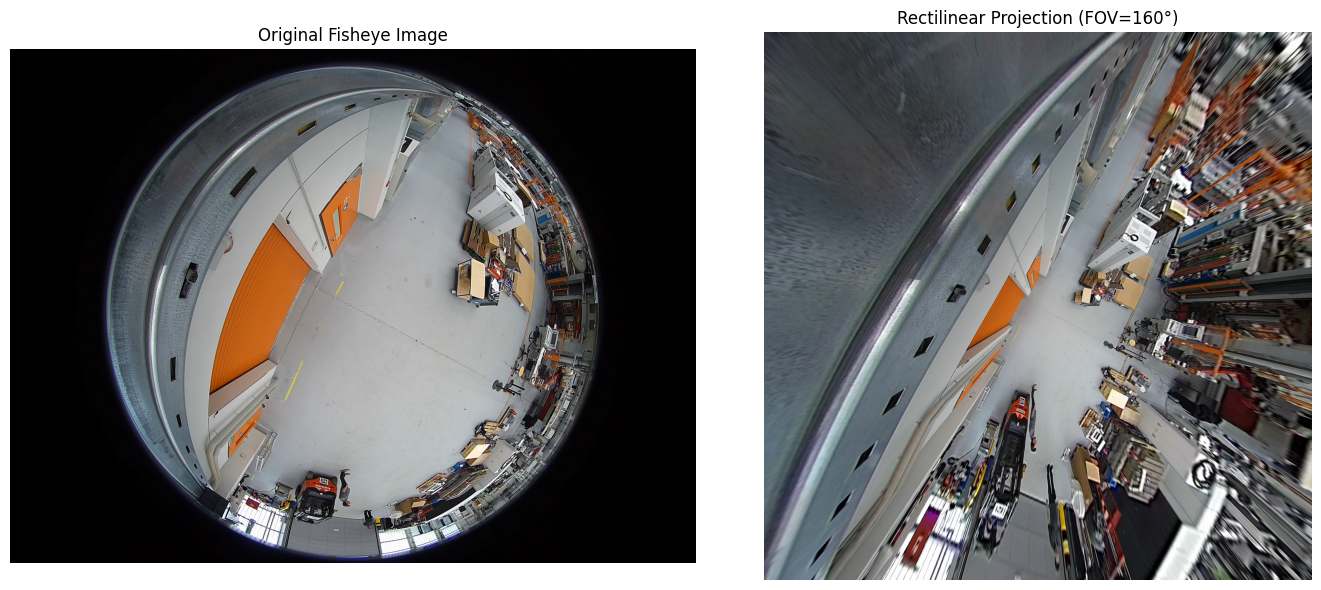

Fisheye Points:
 [[1200.  900.]
 [1400. 1000.]
 [1000. 1100.]]
→ Rectilinear Points:
 [[1243.7966 1252.8474]
 [1319.1193 1290.5321]
 [1158.1217 1332.7041]]


In [11]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# --- FISHEYE CAMERA PARAMETERS ---
fisheye_params = {
    "width": 2592,
    "height": 1944,
    "cx": 1296.0,
    "cy": 972.0,
    "radius": 952.56,
    "theta_max_rad": 1.5708   # ~90° half-FOV, 180° total fisheye coverage
}

fisheye_img = cv2.imread("20251104_115055.png")
Hf, Wf = fisheye_params["height"], fisheye_params["width"]
cx_f, cy_f = fisheye_params["cx"], fisheye_params["cy"]
radius, theta_max = fisheye_params["radius"], fisheye_params["theta_max_rad"]

# --- RECTILINEAR OUTPUT PARAMETERS ---
RECT_W, RECT_H = 2560, 2560
VIEW_FOV = 160.0
VIEW_FOV_RAD = np.deg2rad(VIEW_FOV)

# Compute virtual rectilinear focal length (pixel units)
focal = (RECT_W / 2) / np.tan(VIEW_FOV_RAD / 2)

# --- RECTILINEAR CAMERA MATRIX ---
K_rect = np.array([[focal, 0.0, RECT_W / 2],
                   [0.0, focal, RECT_H / 2],
                   [0.0, 0.0, 1.0]], dtype=np.float64)

# --- FISHEYE CAMERA MATRIX (EQUI-DISTANT MODEL) ---
f_fish = radius / theta_max   # r = f_fish * theta
K_fish = np.array([[f_fish, 0.0, cx_f],
                   [0.0, f_fish, cy_f],
                   [0.0, 0.0, 1.0]], dtype=np.float64)

# --- OPTIONAL DISTORTION (set to zeros if uncalibrated) ---
D_fish = np.zeros((4, 1))

# ======================================================================
#                   FISHEYE → RECTILINEAR IMAGE REMAP
# ======================================================================

x_rect, y_rect = np.meshgrid(np.arange(RECT_W), np.arange(RECT_H))
x_norm = (x_rect - RECT_W / 2) / focal
y_norm = (y_rect - RECT_H / 2) / focal
z = np.ones_like(x_norm)

dirs = np.stack([x_norm, y_norm, z], axis=-1)
r = np.linalg.norm(dirs, axis=-1)
dirs /= np.maximum(r, 1e-8)[..., None]

# Convert to spherical coordinates
theta = np.arccos(dirs[..., 2])
phi = np.arctan2(dirs[..., 1], dirs[..., 0])
theta = np.minimum(theta, theta_max)

# Fisheye projection (equidistant)
r_fish = radius * (theta / theta_max)
u_fish = cx_f + r_fish * np.cos(phi)
v_fish = cy_f + r_fish * np.sin(phi)

map_x = u_fish.astype(np.float32)
map_y = v_fish.astype(np.float32)

rectilinear = cv2.remap(fisheye_img, map_x, map_y,
                        interpolation=cv2.INTER_LINEAR,
                        borderMode=cv2.BORDER_CONSTANT)

# ======================================================================
#                       VISUALIZATION
# ======================================================================

orig_rgb = cv2.cvtColor(fisheye_img, cv2.COLOR_BGR2RGB)
rect_rgb = cv2.cvtColor(rectilinear, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.title("Original Fisheye Image")
plt.imshow(orig_rgb)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title(f"Rectilinear Projection (FOV={VIEW_FOV:.0f}°)")
plt.imshow(rect_rgb)
plt.axis("off")
plt.tight_layout()
plt.show()

# ======================================================================
#                POINT TRANSFER: FISHEYE → RECTILINEAR
# ======================================================================

# Example: define a few fisheye image points to transfer
fisheye_points = np.array([[[1200.0, 900.0]],
                           [[1400.0, 1000.0]],
                           [[1000.0, 1100.0]]], dtype=np.float32)

# Use OpenCV to undistort (fisheye model) and project into rectilinear space
rect_points = cv2.fisheye.undistortPoints(fisheye_points, K_fish, D_fish, P=K_rect)

print("Fisheye Points:\n", fisheye_points.reshape(-1, 2))
print("→ Rectilinear Points:\n", rect_points.reshape(-1, 2))


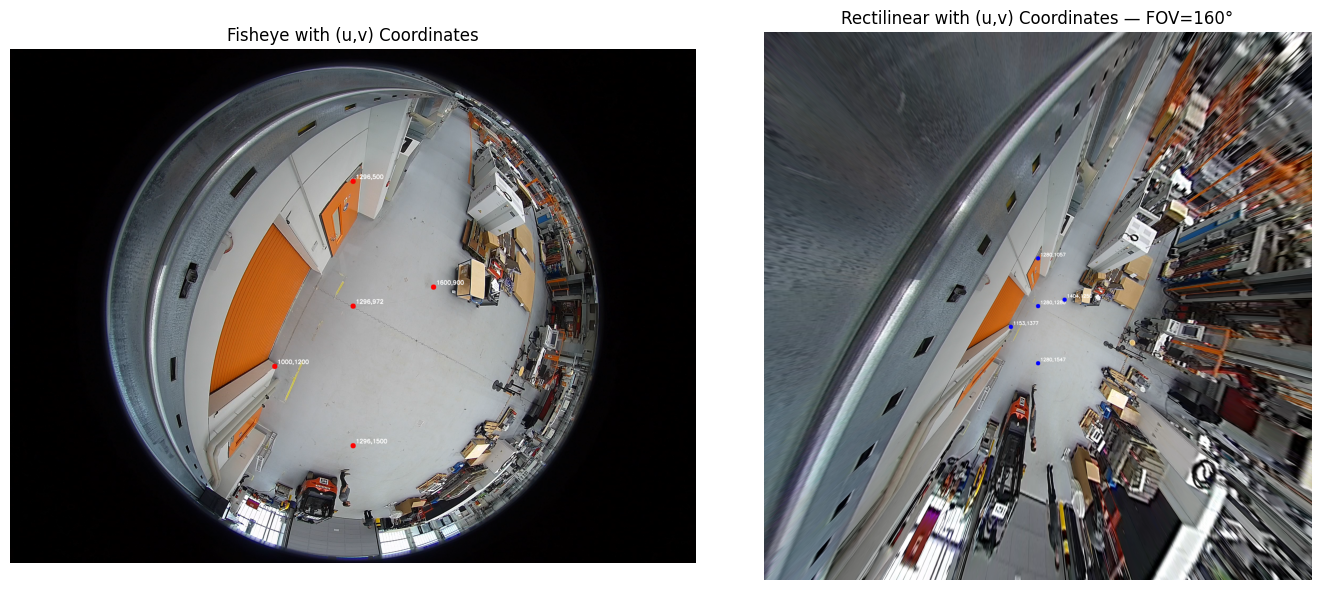

In [12]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# --- FISHEYE CAMERA PARAMETERS ---
fisheye_params = {
    "width": 2592,
    "height": 1944,
    "cx": 1296.0,
    "cy": 972.0,
    "radius": 952.56,
    "theta_max_rad": 1.5708  # 90° half-FOV (180° total)
}

fisheye_img = cv2.imread("20251104_115055.png")
Hf, Wf = fisheye_params["height"], fisheye_params["width"]
cx_f, cy_f = fisheye_params["cx"], fisheye_params["cy"]
radius, theta_max = fisheye_params["radius"], fisheye_params["theta_max_rad"]

# --- RECTILINEAR OUTPUT PARAMETERS ---
RECT_W, RECT_H = 2560, 2560
VIEW_FOV = 160.0
VIEW_FOV_RAD = np.deg2rad(VIEW_FOV)
focal = (RECT_W / 2) / np.tan(VIEW_FOV_RAD / 2)

# --- CAMERA MATRICES ---
K_rect = np.array([[focal, 0.0, RECT_W / 2],
                   [0.0, focal, RECT_H / 2],
                   [0.0, 0.0, 1.0]], dtype=np.float64)

f_fish = radius / theta_max
K_fish = np.array([[f_fish, 0.0, cx_f],
                   [0.0, f_fish, cy_f],
                   [0.0, 0.0, 1.0]], dtype=np.float64)
D_fish = np.zeros((4, 1))  # No distortion used

# ================================================================
#              FISHEYE → RECTILINEAR IMAGE REMAP
# ================================================================
x_rect, y_rect = np.meshgrid(np.arange(RECT_W), np.arange(RECT_H))
x_norm = (x_rect - RECT_W / 2) / focal
y_norm = (y_rect - RECT_H / 2) / focal
z = np.ones_like(x_norm)

dirs = np.stack([x_norm, y_norm, z], axis=-1)
r = np.linalg.norm(dirs, axis=-1)
dirs /= np.maximum(r, 1e-8)[..., None]

theta = np.arccos(dirs[..., 2])
phi = np.arctan2(dirs[..., 1], dirs[..., 0])
theta = np.minimum(theta, theta_max)

r_fish = radius * (theta / theta_max)
u_fish = cx_f + r_fish * np.cos(phi)
v_fish = cy_f + r_fish * np.sin(phi)

map_x = u_fish.astype(np.float32)
map_y = v_fish.astype(np.float32)

rectilinear = cv2.remap(fisheye_img, map_x, map_y,
                        interpolation=cv2.INTER_LINEAR,
                        borderMode=cv2.BORDER_CONSTANT)

# ================================================================
#              DEFINE & TRANSFER TEST POINTS
# ================================================================
fisheye_points = np.array([
    [[1296, 972]],    # center
    [[1600, 900]],    # right-upper
    [[1000, 1200]],   # left-lower
    [[1296, 500]],    # top-center
    [[1296, 1500]]    # bottom-center
], dtype=np.float32)

rect_points = cv2.fisheye.undistortPoints(fisheye_points, K_fish, D_fish, P=K_rect)
rect_points = rect_points.reshape(-1, 2)

# ================================================================
#              DRAW POINTS + PRINT COORDINATES ON IMAGES
# ================================================================
fisheye_vis = fisheye_img.copy()
rect_vis = rectilinear.copy()

for i, (pf, pr) in enumerate(zip(fisheye_points.reshape(-1, 2), rect_points)):
    # Fisheye (red)
    cv2.circle(fisheye_vis, (int(pf[0]), int(pf[1])), 10, (0, 0, 255), -1)
    text_f = f"{int(pf[0])},{int(pf[1])}"
    cv2.putText(fisheye_vis, text_f, (int(pf[0]) + 10, int(pf[1]) - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    # Rectilinear (blue)
    cv2.circle(rect_vis, (int(pr[0]), int(pr[1])), 10, (255, 0, 0), -1)
    text_r = f"{int(pr[0])},{int(pr[1])}"
    cv2.putText(rect_vis, text_r, (int(pr[0]) + 10, int(pr[1]) - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

# Convert to RGB for display
fisheye_vis_rgb = cv2.cvtColor(fisheye_vis, cv2.COLOR_BGR2RGB)
rect_vis_rgb = cv2.cvtColor(rect_vis, cv2.COLOR_BGR2RGB)

# ================================================================
#                      DISPLAY RESULTS
# ================================================================
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.title("Fisheye with (u,v) Coordinates")
plt.imshow(fisheye_vis_rgb)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title(f"Rectilinear with (u,v) Coordinates — FOV={VIEW_FOV:.0f}°")
plt.imshow(rect_vis_rgb)
plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
---------------------------------------------------------------------------
error                                     Traceback (most recent call last)
Cell In[25], line 87
     83 criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-6)
     85 gray_shape = gray.shape[::-1]
---> 87 rms, K, D, rvecs, tvecs = cv2.fisheye.calibrate(
     88     valid_obj,
     89     valid_img,
     90     gray_shape,
     91     K,
     92     D,
     93     None,
     94     None,
     95     flags,
     96     criteria
     97 )
     99 print("\n✅ Calibration Complete")
    100 print(f"RMS reprojection error: {rms:.4f}")


Found 9 images for calibration
✅ Using 9 valid frames for calibration


error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\calib3d\src\fisheye.cpp:1453: error: (-215:Assertion failed) fabs(norm_u1) > 0 in function 'cv::internal::InitExtrinsics'


In [30]:
import cv2
import numpy as np
import glob
import os

# ------------------------------------------------------------
# ⚙️ USER SETTINGS
# ------------------------------------------------------------
CHECKERBOARD = (10, 7)  # number of inner corners (columns, rows)
square_size = 0.025     # size of one square in meters (adjust!)
image_dir = "checkerboard_frames"  # folder with calibration images
output_file = "fisheye_calibration_data.npz"

# ------------------------------------------------------------
# 🧩 Setup
# ------------------------------------------------------------
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-6)

# Prepare object points (0,0,0), (1,0,0), ..., (9,6,0)
objp = np.zeros((1, CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[0, :, :2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)
objp *= square_size

objpoints = []  # 3D points
imgpoints = []  # 2D points

# ------------------------------------------------------------
# 📸 Load images
# ------------------------------------------------------------
images = sorted(glob.glob(os.path.join(image_dir, "*.jpg")) +
                glob.glob(os.path.join(image_dir, "*.png")))

if not images:
    raise RuntimeError(f"No images found in: {os.path.abspath(image_dir)}")

print(f"Found {len(images)} calibration images.\n")

# ------------------------------------------------------------
# 🔍 Detect checkerboard corners
# ------------------------------------------------------------
for fname in images:
    img = cv2.imread(fname)
    if img is None:
        print(f"⚠️ Could not read {fname}")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD,
                    flags=cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE)

    if not ret:
        print(f"❌ Corners not detected in {os.path.basename(fname)}")
        continue

    # Refine corner positions
    corners_refined = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)

    # Filter: reject if corners near border (likely partial pattern)
    x_min, y_min = corners_refined.min(axis=0)[0]
    x_max, y_max = corners_refined.max(axis=0)[0]
    h, w = gray.shape
    border_thresh = 10  # pixels
    if (x_min < border_thresh or y_min < border_thresh or
        x_max > w - border_thresh or y_max > h - border_thresh):
        print(f"⚠️ Skipping {os.path.basename(fname)} (pattern touches border)")
        continue

    objpoints.append(objp)
    imgpoints.append(corners_refined)

    # Visual check
    vis = img.copy()
    cv2.drawChessboardCorners(vis, CHECKERBOARD, corners_refined, True)
    cv2.imshow("Detected Corners", vis)
    cv2.waitKey(250)

cv2.destroyAllWindows()

N = len(objpoints)
if N < 5:
    raise RuntimeError(f"❌ Only {N} valid frames found. Capture more varied checkerboard images!")

print(f"✅ {N} valid frames will be used for calibration.\n")

# ------------------------------------------------------------
# 🎯 Fisheye calibration
# ------------------------------------------------------------
K = np.zeros((3, 3))
D = np.zeros((4, 1))

flags = (cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC |
         cv2.fisheye.CALIB_FIX_SKEW |
         cv2.fisheye.CALIB_CHECK_COND)

rms, K, D, rvecs, tvecs = cv2.fisheye.calibrate(
    objectPoints=objpoints,
    imagePoints=imgpoints,
    image_size=gray.shape[::-1],
    K=K,
    D=D,
    rvecs=None,
    tvecs=None,
    flags=flags,
    criteria=criteria
)

# ------------------------------------------------------------
# 🧮 Results
# ------------------------------------------------------------
print("\n✅ Calibration successful!")
print(f"RMS Reprojection Error: {rms:.4f}")
print("Camera Matrix (K):\n", K)
print("Distortion Coefficients (D):\n", D.ravel())

np.savez(output_file, K=K, D=D, rms=rms)
print(f"\n💾 Calibration data saved to {output_file}")

# ------------------------------------------------------------
# 📊 Per-frame reprojection errors
# ------------------------------------------------------------
total_err = 0
for i in range(N):
    imgpoints2, _ = cv2.fisheye.projectPoints(objpoints[i], rvecs[i], tvecs[i], K, D)
    err = cv2.norm(imgpoints[i], imgpoints2, cv2.NORM_L2) / len(imgpoints2)
    total_err += err
    print(f"Frame {i+1}: Reprojection error = {err:.4f}px")

mean_err = total_err / N
print(f"\n📏 Mean reprojection error: {mean_err:.4f}px")

# ------------------------------------------------------------
# 🧪 Undistort test image
# ------------------------------------------------------------
test_img = cv2.imread(images[0])
h, w = test_img.shape[:2]

map1, map2 = cv2.fisheye.initUndistortRectifyMap(
    K, D, np.eye(3), K, (w, h), cv2.CV_16SC2
)
undistorted = cv2.remap(test_img, map1, map2, interpolation=cv2.INTER_LINEAR)

combined = np.hstack((test_img, undistorted))
cv2.imshow("Left: Original | Right: Undistorted", combined)
cv2.waitKey(0)
cv2.destroyAllWindows()


Found 181 calibration images.

❌ Corners not detected in frame_01323.jpg
❌ Corners not detected in frame_01324.jpg
❌ Corners not detected in frame_01325.jpg
✅ 178 valid frames will be used for calibration.



error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\calib3d\src\fisheye.cpp:1502: error: (-3:Internal error) CALIB_CHECK_COND - Ill-conditioned matrix for input array 4 in function 'cv::internal::CalibrateExtrinsics'


In [1]:
import cv2
import numpy as np
import glob
import os

# =====================================================
# USER PARAMETERS
# =====================================================
images_glob = "frames_for_cali/*.jpg"   # path to checkerboard images
pattern_size = (10, 7)                  # (inner corners per row, inner corners per column)
square_size = 0.025                     # physical size of one square (in meters or any unit)
# =====================================================

# Termination criteria for cornerSubPix
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-6)


In [2]:
# 3D points for one checkerboard (same for all images)
objp = np.zeros((1, pattern_size[0] * pattern_size[1], 3), np.float32)
objp[0, :, :2] = np.indices(pattern_size).T.reshape(-1, 2)
objp *= square_size

objpoints = []  # 3D real-world points
imgpoints = []  # 2D image points


In [3]:
image_paths = sorted(glob.glob(images_glob))
if len(image_paths) == 0:
    raise SystemExit(f"No images found at: {images_glob}")

print(f"Found {len(image_paths)} images for calibration.")


Found 16 images for calibration.


In [4]:
img_shape = None

for fname in image_paths:
    img = cv2.imread(fname)
    if img is None:
        print(f"Cannot read: {fname}")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if img_shape is None:
        img_shape = gray.shape[::-1]  # (width, height)

    # Detect checkerboard corners
    found, corners = cv2.findChessboardCorners(
        gray,
        pattern_size,
        flags=cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE
    )

    if found:
        # Refine to subpixel accuracy
        corners_refined = cv2.cornerSubPix(
            gray, corners, (11, 11), (-1, -1),
            (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 50, 0.001)
        )
        objpoints.append(objp)
        imgpoints.append(corners_refined)

        # (Optional) visualize detected corners
        vis = cv2.drawChessboardCorners(img.copy(), pattern_size, corners_refined, found)
        cv2.imshow("Corners", vis)
        cv2.waitKey(100)
    else:
        print(f"⚠️ Chessboard not found in {os.path.basename(fname)}")

cv2.destroyAllWindows()

if len(objpoints) < 8:
    raise SystemExit("Need at least 8–10 valid images for calibration.")


⚠️ Chessboard not found in frame_01323.jpg


In [9]:
def estimate_board_tilt(corners, img_shape):
    # normalize coordinates around image center
    h, w = img_shape
    cx, cy = w/2, h/2
    mean = corners.mean(axis=0)[0]
    dx, dy = mean - np.array([cx, cy])
    dist = np.sqrt(dx**2 + dy**2)
    return dist / max(w, h)

tilt_scores = [estimate_board_tilt(imgp, gray.shape) for imgp in imgpoints]
for i, s in enumerate(tilt_scores):
    print(f"Image {i}: tilt diversity score = {s:.3f}")


Image 0: tilt diversity score = 0.043
Image 1: tilt diversity score = 0.051
Image 2: tilt diversity score = 0.140
Image 3: tilt diversity score = 0.083
Image 4: tilt diversity score = 0.274
Image 5: tilt diversity score = 0.221
Image 6: tilt diversity score = 0.203
Image 7: tilt diversity score = 0.177
Image 8: tilt diversity score = 0.106
Image 9: tilt diversity score = 0.140
Image 10: tilt diversity score = 0.166
Image 11: tilt diversity score = 0.096
Image 12: tilt diversity score = 0.125
Image 13: tilt diversity score = 0.189
Image 14: tilt diversity score = 0.191


In [10]:
import cv2
import numpy as np
import glob
import os

# just to synthetically warp some images
def perspective_tilt(img, tilt_strength=0.15):
    h, w = img.shape[:2]
    src = np.float32([[0,0],[w,0],[w,h],[0,h]])
    dx = w * tilt_strength
    dy = h * tilt_strength
    dst = np.float32([[dx, dy],[w-dx, dy],[w, h-dy],[0, h-dy]])
    M = cv2.getPerspectiveTransform(src, dst)
    return cv2.warpPerspective(img, M, (w,h))

images = sorted(glob.glob("frames_for_cali/*.jpg"))
for i,f in enumerate(images[:3]):   # tilt first few for testing
    img = cv2.imread(f)
    warped = perspective_tilt(img, 0.2)
    cv2.imwrite(f"frames_for_cali/tilted_{i}.jpg", warped)


In [7]:
import cv2
import numpy as np

# ... after you filled objpoints, imgpoints, gray ...

K = np.zeros((3, 3))
D = np.zeros((4, 1))
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-6)

flags = (cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC |
         cv2.fisheye.CALIB_FIX_SKEW)

# Compute diversity score for each frame
tilt_scores = [estimate_board_tilt(imgp, gray.shape) for imgp in imgpoints]
diverse_idx = np.argsort(tilt_scores)[::-1][:10]  # pick top 10 diverse frames

obj_sel = [objpoints[i] for i in diverse_idx]
img_sel = [imgpoints[i] for i in diverse_idx]

print(f"Calibrating fisheye camera with {len(obj_sel)} diverse images...")

try:
    rms, K, D, rvecs, tvecs = cv2.fisheye.calibrate(
        objectPoints=obj_sel,
        imagePoints=img_sel,
        image_size=gray.shape[::-1],
        K=K,
        D=D,
        rvecs=None,
        tvecs=None,
        flags=flags,
        criteria=criteria
    )
    print(f"\n✅ Calibration successful! RMS error = {rms:.4f}")
    print("K:\n", K)
    print("D:\n", D.ravel())
except cv2.error as e:
    print("❌ Calibration failed — still too little pose variation.")
    print("Try capturing more tilted and edge images.")


Calibrating fisheye camera with 10 diverse images...
❌ Calibration failed — still too little pose variation.
Try capturing more tilted and edge images.


In [36]:
total_error = 0
total_points = 0

for i in range(len(objpoints)):
    projected, _ = cv2.fisheye.projectPoints(
        objpoints[i], rvecs[i], tvecs[i], K, D
    )
    err = np.linalg.norm(imgpoints[i].reshape(-1, 2) - projected.reshape(-1, 2), axis=1)
    total_error += np.sum(err)
    total_points += len(err)

mean_error = total_error / total_points
print(f"Mean reprojection error: {mean_error:.4f} pixels")

# Save results
np.savez("fisheye_calibration.npz", K=K, D=D, img_shape=img_shape, rms=rms)
print("✅ Calibration parameters saved to fisheye_calibration.npz")


Mean reprojection error: 537.0368 pixels
✅ Calibration parameters saved to fisheye_calibration.npz


In [ ]:
import cv2
import numpy as np
import glob
import os

# ------------------------------------------------------------
# ⚙️ USER SETTINGS
# ------------------------------------------------------------
CHECKERBOARD = (10, 7)  # number of inner corners (columns, rows)
square_size = 0.025     # size of one square in meters (adjust!)
image_dir = "calib_images"  # folder with calibration images
output_file = "fisheye_calibration_data.npz"

# ------------------------------------------------------------
# 🧩 Setup
# ------------------------------------------------------------
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-6)

# Prepare object points (0,0,0), (1,0,0), ..., (9,6,0)
objp = np.zeros((1, CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[0, :, :2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)
objp *= square_size

objpoints = []  # 3D points
imgpoints = []  # 2D points

# ------------------------------------------------------------
# 📸 Load images
# ------------------------------------------------------------
images = sorted(glob.glob(os.path.join(image_dir, "*.jpg")) +
                glob.glob(os.path.join(image_dir, "*.png")))

if not images:
    raise RuntimeError(f"No images found in: {os.path.abspath(image_dir)}")

print(f"Found {len(images)} calibration images.\n")

# ------------------------------------------------------------
# 🔍 Detect checkerboard corners
# ------------------------------------------------------------
for fname in images:
    img = cv2.imread(fname)
    if img is None:
        print(f"⚠️ Could not read {fname}")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD,
                    flags=cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE)

    if not ret:
        print(f"❌ Corners not detected in {os.path.basename(fname)}")
        continue

    # Refine corner positions
    corners_refined = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)

    # Filter: reject if corners near border (likely partial pattern)
    x_min, y_min = corners_refined.min(axis=0)[0]
    x_max, y_max = corners_refined.max(axis=0)[0]
    h, w = gray.shape
    border_thresh = 10  # pixels
    if (x_min < border_thresh or y_min < border_thresh or
        x_max > w - border_thresh or y_max > h - border_thresh):
        print(f"⚠️ Skipping {os.path.basename(fname)} (pattern touches border)")
        continue

    objpoints.append(objp)
    imgpoints.append(corners_refined)

    # Visual check
    vis = img.copy()
    cv2.drawChessboardCorners(vis, CHECKERBOARD, corners_refined, True)
    cv2.imshow("Detected Corners", vis)
    cv2.waitKey(250)

cv2.destroyAllWindows()

N = len(objpoints)
if N < 5:
    raise RuntimeError(f"❌ Only {N} valid frames found. Capture more varied checkerboard images!")

print(f"✅ {N} valid frames will be used for calibration.\n")

# ------------------------------------------------------------
# 🎯 Fisheye calibration
# ------------------------------------------------------------
K = np.zeros((3, 3))
D = np.zeros((4, 1))

flags = (cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC |
         cv2.fisheye.CALIB_FIX_SKEW |
         cv2.fisheye.CALIB_CHECK_COND)

rms, K, D, rvecs, tvecs = cv2.fisheye.calibrate(
    objectPoints=objpoints,
    imagePoints=imgpoints,
    image_size=gray.shape[::-1],
    K=K,
    D=D,
    rvecs=None,
    tvecs=None,
    flags=flags,
    criteria=criteria
)

# ------------------------------------------------------------
# 🧮 Results
# ------------------------------------------------------------
print("\n✅ Calibration successful!")
print(f"RMS Reprojection Error: {rms:.4f}")
print("Camera Matrix (K):\n", K)
print("Distortion Coefficients (D):\n", D.ravel())

np.savez(output_file, K=K, D=D, rms=rms)
print(f"\n💾 Calibration data saved to {output_file}")

# ------------------------------------------------------------
# 📊 Per-frame reprojection errors
# ------------------------------------------------------------
total_err = 0
for i in range(N):
    imgpoints2, _ = cv2.fisheye.projectPoints(objpoints[i], rvecs[i], tvecs[i], K, D)
    err = cv2.norm(imgpoints[i], imgpoints2, cv2.NORM_L2) / len(imgpoints2)
    total_err += err
    print(f"Frame {i+1}: Reprojection error = {err:.4f}px")

mean_err = total_err / N
print(f"\n📏 Mean reprojection error: {mean_err:.4f}px")

# ------------------------------------------------------------
# 🧪 Undistort test image
# ------------------------------------------------------------
test_img = cv2.imread(images[0])
h, w = test_img.shape[:2]

map1, map2 = cv2.fisheye.initUndistortRectifyMap(
    K, D, np.eye(3), K, (w, h), cv2.CV_16SC2
)
undistorted = cv2.remap(test_img, map1, map2, interpolation=cv2.INTER_LINEAR)

combined = np.hstack((test_img, undistorted))
cv2.imshow("Left: Original | Right: Undistorted", combined)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [2]:
import cv2
import numpy as np
import glob
import os

CHECKERBOARD = (10, 7)
image_dir = "selected_frames"
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-6)

images = sorted(glob.glob(os.path.join(image_dir, "*.jpg")) + glob.glob(os.path.join(image_dir, "*.png")))

print(f"Scanning {len(images)} frames...")

def corner_condition_score(corners, shape):
    h, w = shape
    cx, cy = w / 2, h / 2
    corners = corners.reshape(-1,2)
    mean = np.mean(corners, axis=0)
    spread = np.std(corners, axis=0).mean()
    dx, dy = mean - np.array([cx, cy])
    offset = np.sqrt(dx**2 + dy**2) / max(w,h)
    return offset, spread / (max(w,h) * 0.5)

bad_files = []
scores = []

for idx, f in enumerate(images):
    img = cv2.imread(f)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD)
    if not ret:
        print(f"❌ No corners in {f}")
        bad_files.append(f)
        continue
    corners = cv2.cornerSubPix(gray, corners, (11,11), (-1,-1), criteria)
    offset, spread = corner_condition_score(corners, gray.shape)
    scores.append((f, offset, spread))

print("\n📊 Board pose diagnostics (offset, spread):")
for i, (f, offset, spread) in enumerate(scores):
    print(f"{i:03d} {os.path.basename(f)} offset={offset:.3f} spread={spread:.3f}")

# Filter: remove nearly fronto-parallel / centered boards
good = [f for f, o, s in scores if (o > 0.08 and s > 0.20)]
bad = [f for f, o, s in scores if (o <= 0.08 or s <= 0.20)]

print(f"\n✅ Good frames: {len(good)} / {len(images)}")
print(f"❌ Likely bad: {len(bad)}")

os.makedirs("filtered_good", exist_ok=True)
os.makedirs("filtered_bad", exist_ok=True)

for f in good:
    os.rename(f, os.path.join("filtered_good", os.path.basename(f)))
for f in bad:
    os.rename(f, os.path.join("filtered_bad", os.path.basename(f)))

print("\n✅ Moved good frames to 'filtered_good/'")
print("❌ Moved low-diversity or ill-conditioned frames to 'filtered_bad/'")


Scanning 60 frames...

📊 Board pose diagnostics (offset, spread):
000 frame_0349.jpg offset=0.212 spread=0.098
001 frame_0350.jpg offset=0.218 spread=0.095
002 frame_0351.jpg offset=0.225 spread=0.091
003 frame_0352.jpg offset=0.231 spread=0.088
004 frame_0353.jpg offset=0.237 spread=0.084
005 frame_0354.jpg offset=0.243 spread=0.081
006 frame_0355.jpg offset=0.248 spread=0.079
007 frame_0356.jpg offset=0.254 spread=0.077
008 frame_0367.jpg offset=0.269 spread=0.069
009 frame_0368.jpg offset=0.268 spread=0.068
010 frame_0369.jpg offset=0.268 spread=0.068
011 frame_0370.jpg offset=0.269 spread=0.068
012 frame_0371.jpg offset=0.270 spread=0.067
013 frame_0372.jpg offset=0.272 spread=0.067
014 frame_0373.jpg offset=0.274 spread=0.067
015 frame_0374.jpg offset=0.276 spread=0.067
016 frame_0375.jpg offset=0.277 spread=0.068
017 frame_0378.jpg offset=0.278 spread=0.070
018 frame_0379.jpg offset=0.275 spread=0.071
019 frame_0380.jpg offset=0.271 spread=0.073
020 frame_0381.jpg offset=0.264 sp

In [7]:
import cv2
import numpy as np
import glob

# pattern details
pattern_size = (10, 7)
square_size = 0.025  # meters or any consistent unit

# prepare 3D object points
objp = np.zeros((1, pattern_size[0] * pattern_size[1], 3), np.float32)
objp[0, :, :2] = np.mgrid[0:pattern_size[0], 0:pattern_size[1]].T.reshape(-1, 2)
objp *= square_size

objpoints_ = []
imgpoints_ = []

images = glob.glob("selected_frames_/*.jpg")

for fname in images:
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- Detect corners using fisheye-friendly detector ---
    ret, corners = cv2.findChessboardCornersSB(
        gray, pattern_size,
        flags=cv2.CALIB_CB_EXHAUSTIVE + cv2.CALIB_CB_ACCURACY
    )

    if ret:
        # --- Refine detected corners to subpixel precision ---
        corners = cv2.cornerSubPix(
            gray, corners,
            (5,5), (-1,-1),
            (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-6)
        )

        # Draw and display
        cv2.drawChessboardCorners(img, pattern_size, corners, ret)
        cv2.imshow('Detected Corners', img)
        cv2.waitKey(100)

        # Store points
        objpoints_.append(objp)
        imgpoints_.append(corners)
    else:
        print(f"❌ Chessboard not found in {fname}")

cv2.destroyAllWindows()


❌ Chessboard not found in selected_frames_\frame_0354.jpg
❌ Chessboard not found in selected_frames_\frame_0367.jpg
❌ Chessboard not found in selected_frames_\frame_0368.jpg
❌ Chessboard not found in selected_frames_\frame_0380.jpg
❌ Chessboard not found in selected_frames_\frame_1044.jpg


In [9]:
objpoints_

[array([[[0.        , 0.        , 0.        ],
         [0.025     , 0.        , 0.        ],
         [0.05      , 0.        , 0.        ],
         [0.075     , 0.        , 0.        ],
         [0.1       , 0.        , 0.        ],
         [0.125     , 0.        , 0.        ],
         [0.15      , 0.        , 0.        ],
         [0.175     , 0.        , 0.        ],
         [0.2       , 0.        , 0.        ],
         [0.22500001, 0.        , 0.        ],
         [0.        , 0.025     , 0.        ],
         [0.025     , 0.025     , 0.        ],
         [0.05      , 0.025     , 0.        ],
         [0.075     , 0.025     , 0.        ],
         [0.1       , 0.025     , 0.        ],
         [0.125     , 0.025     , 0.        ],
         [0.15      , 0.025     , 0.        ],
         [0.175     , 0.025     , 0.        ],
         [0.2       , 0.025     , 0.        ],
         [0.22500001, 0.025     , 0.        ],
         [0.        , 0.05      , 0.        ],
         [0.0

In [ ]:
import cv2
import numpy as np
import glob
import os

# ---------------- USER SETTINGS ----------------
pattern_size = (10, 7)          # inner corners (cols, rows)
square_size = 0.025             # in meters (real square size)
image_folder = "selected_frames_"  # folder with your fisheye calibration images
min_required = 15              # minimum valid images required
output_file = "fisheye_calibration_data.npz"
# ------------------------------------------------


# === Prepare 3D object points ===
objp = np.zeros((1, pattern_size[0] * pattern_size[1], 3), np.float32)
objp[0, :, :2] = np.mgrid[0:pattern_size[0], 0:pattern_size[1]].T.reshape(-1, 2)
objp *= square_size

objpoints_, imgpoints_ = [], []

images = sorted(glob.glob(os.path.join(image_folder, "*.jpg")))
print(f"Found {len(images)} images to process.\n")

img_shape = None

for fname in images:
    img = cv2.imread(fname)
    if img is None:
        print(f"⚠️ Could not read {fname}")
        continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Ensure all images have same resolution
    if img_shape is None:
        img_shape = gray.shape[::-1]
    elif gray.shape[::-1] != img_shape:
        print(f"⚠️ Skipping {fname} (inconsistent size: {gray.shape[::-1]} != {img_shape})")
        continue

    # Detect chessboard corners (fisheye-friendly)
    ret, corners = cv2.findChessboardCornersSB(
        gray, pattern_size,
        flags=cv2.CALIB_CB_EXHAUSTIVE + cv2.CALIB_CB_ACCURACY
    )

    if ret:
        # Refine corners to subpixel accuracy
        corners = cv2.cornerSubPix(
            gray, corners,
            (5, 5), (-1, -1),
            (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-6)
        )

        # Draw and show progress (optional)
        disp = img.copy()
        cv2.drawChessboardCorners(disp, pattern_size, corners, ret)
        cv2.imshow("Detected Corners", disp)
        cv2.waitKey(100)

        # Store in correct shape & dtype
        objpoints_.append(objp.astype(np.float32))
        imgpoints_.append(corners.reshape(1, -1, 2).astype(np.float32))
    else:
        print(f"❌ Chessboard not found in {os.path.basename(fname)}")

cv2.destroyAllWindows()

print(f"\n✅ Detected corners in {len(objpoints_)} images.")


# === Safety checks ===
if len(objpoints_) < min_required:
    raise RuntimeError("❌ Not enough valid detections for calibration. "
                       "You need at least 10–15 good tilted boards.")


# === Helper: safe calibration attempt ===
def safe_fisheye_calibrate(objpoints, imgpoints, img_shape):
    objpoints = [o.reshape(1, -1, 3).astype(np.float32) for o in objpoints]
    imgpoints = [i.reshape(1, -1, 2).astype(np.float32) for i in imgpoints]

    print("\nStarting fisheye calibration...")
    K = np.zeros((3, 3))
    D = np.zeros((4, 1))
    flags = 0  # start simple
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 200, 1e-6)

    for i in reversed(range(len(objpoints))):
        try:
            rms, K, D, rvecs, tvecs = cv2.fisheye.calibrate(
                objectPoints=objpoints,
                imagePoints=imgpoints,
                image_size=img_shape,
                K=K,
                D=D,
                rvecs=None,
                tvecs=None,
                flags=flags,
                criteria=criteria
            )
            print(f"✅ Calibration succeeded with {len(objpoints)} frames (RMS={rms:.4f})")
            return rms, K, D
        except cv2.error as e:
            print(f"⚠️ Failed with {len(objpoints)} frames — removing last and retrying...")
            objpoints.pop()
            imgpoints.pop()
            if len(objpoints) < 5:
                raise RuntimeError("Calibration failed: not enough valid frames left.")
    raise RuntimeError("All frames invalid.")


# === Run calibration safely ===
rms, K, D = safe_fisheye_calibrate(objpoints_, imgpoints_, img_shape)

print("\n✅ Final Calibration Results:")
print(f"RMS Reprojection Error: {rms:.4f}")
print("Camera Matrix (K):\n", K)
print("Distortion Coefficients (D):\n", D.ravel())

# Save calibration data
np.savez(output_file, K=K, D=D, rms=rms)
print(f"📦 Calibration data saved to {output_file}")


# === Test undistortion on one image ===
test_img = cv2.imread(images[0])
h, w = test_img.shape[:2]
balance = 0.0  # try 0.0–1.0

new_K = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
    K, D, (w, h), np.eye(3), balance=balance
)
map1, map2 = cv2.fisheye.initUndistortRectifyMap(
    K, D, np.eye(3), new_K, (w, h), cv2.CV_16SC2
)
undistorted = cv2.remap(test_img, map1, map2, interpolation=cv2.INTER_LINEAR)

cv2.imshow("Original", test_img)
cv2.imshow("Undistorted", undistorted)
cv2.waitKey(0)
cv2.destroyAllWindows()


Found 22 images to process.

❌ Chessboard not found in frame_0354.jpg
❌ Chessboard not found in frame_0367.jpg
❌ Chessboard not found in frame_0368.jpg
❌ Chessboard not found in frame_0380.jpg
❌ Chessboard not found in frame_1044.jpg

✅ Detected corners in 17 images.

Starting fisheye calibration...
✅ Calibration succeeded with 17 frames (RMS=15413651843.9442)

✅ Final Calibration Results:
RMS Reprojection Error: 15413651843.9442
Camera Matrix (K):
 [[ 1.08643686e+04 -3.98938690e+07  1.50646921e+03]
 [ 0.00000000e+00  2.99275448e-02  1.13610141e+03]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Distortion Coefficients (D):
 [  3119.56416718 -25503.02123114 -80742.94279611 397780.46571742]
📦 Calibration data saved to fisheye_calibration_data.npz
